In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.instruments.fixed_rate_loan import FixedRateLoan

In [2]:
# a synthetic retail mortgage loan
mortgage = FixedRateLoan(
    notional = 300000,
    start_date = '2026-03-01',
    maturity_date = '2046-03-01',
    fixed_rate = 0.047,
    payment_frequency = 'M'
)

cf_mortgage = mortgage.generate_cashflows()
display(cf_mortgage)

# sanity checks
print(f"Total payments: {cf_mortgage.shape[0]}")
print(f"Total interest paid: {cf_mortgage.interest.sum():.2f}")
print(f"Total principal paid: {cf_mortgage.principal.sum():.2f}")
print(f"Final outstanding: {cf_mortgage.outstanding_balance.iloc[-1]:.2f}")

,date,principal,interest,total_cashflow,outstanding_balance
0,2026-03-01,750.657847,1175.000000,1925.657847,2.992493e+05
1,2026-04-01,753.597923,1172.059923,1925.657847,2.984957e+05
2,2026-05-01,756.549515,1169.108332,1925.657847,2.977392e+05
3,2026-06-01,759.512668,1166.145179,1925.657847,2.969797e+05
4,2026-07-01,762.487426,1163.170421,1925.657847,2.962172e+05
...,...,...,...,...,...
236,2045-11-01,1888.386131,37.271716,1925.657847,7.627797e+03
237,2045-12-01,1895.782310,29.875537,1925.657847,5.732014e+03
238,2046-01-01,1903.207458,22.450389,1925.657847,3.828807e+03
239,2046-02-01,1910.661687,14.996160,1925.657847,1.918145e+03


Total payments: 241
Total interest paid: 164083.54
Total principal paid: 300000.00
Final outstanding: -0.00


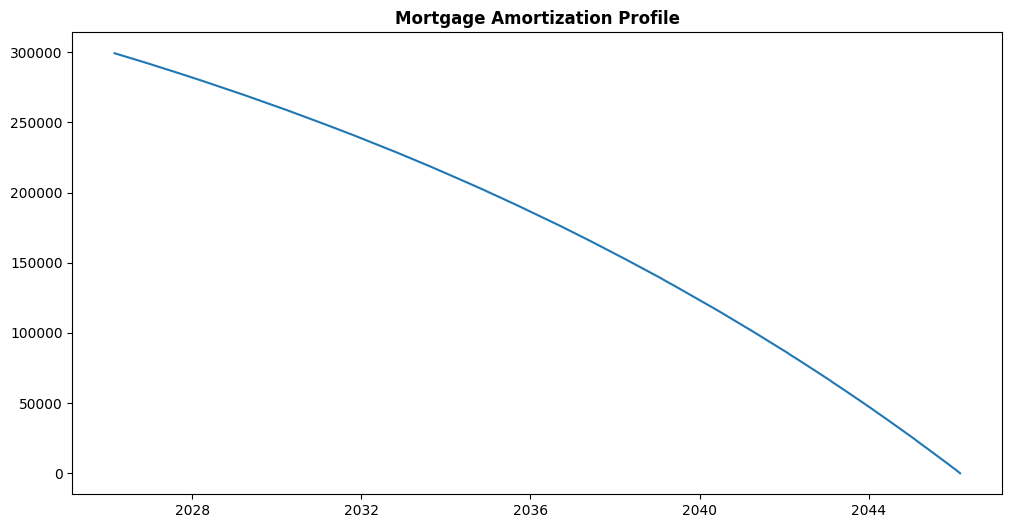

In [3]:
# plotting amortization profile
plt.figure(figsize=(12, 6))
plt.plot(
    cf_mortgage['date'],
    cf_mortgage['outstanding_balance']
)
plt.title('Mortgage Amortization Profile', fontweight = 'bold')
plt.show()

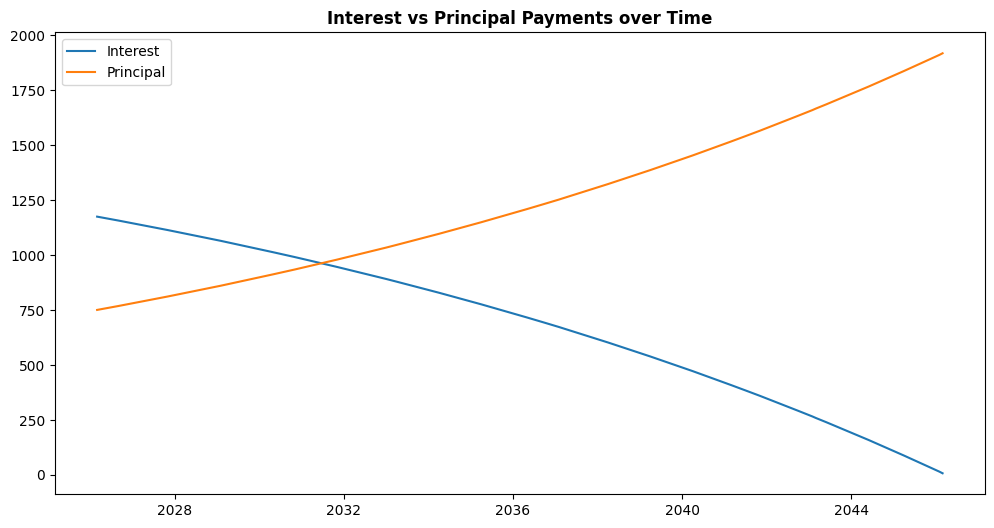

In [4]:
# interest vs principal payments over time
plt.figure(figsize=(12, 6))
plt.plot(
    cf_mortgage['date'],
    cf_mortgage['interest'],
    label = 'Interest'
)
plt.plot(
    cf_mortgage['date'],
    cf_mortgage['principal'],
    label = 'Principal'
)
plt.legend()
plt.title('Interest vs Principal Payments over Time', fontweight = 'bold')
plt.show()

In [5]:
# a synthetic corporate loan
corp_loan = FixedRateLoan(
    notional = 5000000,
    start_date = '2026-03-01',
    maturity_date = '2031-03-01',
    fixed_rate = 0.065,
    payment_frequency = 'Q'
)

cf_corp = corp_loan.generate_cashflows()
display(cf_corp)

# compare corp vs mortgage cfs
print(f"Mortgage avg payments: {cf_mortgage['total_cashflow'].mean():.2f}")
print(f"Corporate Loan avg payments: {cf_corp['total_cashflow'].mean():.2f}")

,date,principal,interest,total_cashflow,outstanding_balance
0,2026-04-01,201687.174050,81250.000000,282937.17405,4.798313e+06
1,2026-07-01,204964.590628,77972.583422,282937.17405,4.593348e+06
2,2026-10-01,208295.265226,74641.908824,282937.17405,4.385053e+06
3,2027-01-01,211680.063286,71257.110764,282937.17405,4.173373e+06
4,2027-04-01,215119.864314,67817.309736,282937.17405,3.958253e+06
5,2027-07-01,218615.562109,64321.611941,282937.17405,3.739637e+06
6,2027-10-01,222168.064994,60769.109056,282937.17405,3.517469e+06
7,2028-01-01,225778.296050,57158.878000,282937.17405,3.291691e+06
8,2028-04-01,229447.193361,53489.980689,282937.17405,3.062244e+06
9,2028-07-01,233175.710253,49761.463797,282937.17405,2.829068e+06


Mortgage avg payments: 1925.66
Corporate Loan avg payments: 282937.17


In [6]:
# aggregate cashflows
portfolio_cf = pd.concat([cf_mortgage, cf_corp])

agg_cf = (
    portfolio_cf
    .groupby('date')
    .agg({'total_cashflow': 'sum'})
    .reset_index()
)

agg_cf.head(12)

,date,total_cashflow
0,2026-03-01,1925.657847
1,2026-04-01,284862.831897
2,2026-05-01,1925.657847
3,2026-06-01,1925.657847
4,2026-07-01,284862.831897
5,2026-08-01,1925.657847
6,2026-09-01,1925.657847
7,2026-10-01,284862.831897
8,2026-11-01,1925.657847
9,2026-12-01,1925.657847
